# Legacy methods, exactly `ml_TESTYYY`'s E1 data

The same pre-rewrite methods as the other notebook, on **exactly the data
`ml_TESTYYY/experiments/e1_toy.py` uses**, fed in **exactly the way that script
feeds it**:

* `make_toy_data(seed=0)` -- seed 0 is that script's `FIGURE_SEED`, the seed
  behind every E1 figure. Its metric tables average over seeds 0..19; a single
  notebook figure corresponds to seed 0.
* 250 training inputs drawn **uniformly** from `[0, 6]` (not a regular grid),
  `sigma = 0.1`, a **500-point** test grid on `[-2, 8]`, `default_rng(0)`.
* Methods are fitted on the **standardised** arrays `x_train_std`, `y_train_std`
  and predict on `x_test_std` -- exactly the three arrays `e1_toy.py` passes.
  The predictive mean and standard deviation are un-standardised again before
  plotting, so the figures are in original `y` units.

`SEED = 0` also drives the legacy methods' own weight initialisation, so one
seed governs the whole notebook.

**Provenance.** `legacy_models.py` is a verbatim `git show 28b7615^:src/models.py`
from `ml_uncertainty_msc`. `legacy_methods.py` is *reconstructed from bytecode* --
the original `src/methods.py` was never committed and survives only as a stale
`__pycache__` entry, so its structure, constants and defaults are read off the
disassembly while local variable names and comments are guesswork.

**This is a probe, not a result.** It reproduces an older, different estimator of
predictive uncertainty (a band of +-2 sigma from a single total standard
deviation, dashed line = clean sin(x)); it is not the current `Prediction`
interface, and its numbers do not belong in the thesis tables.

In [1]:
import sys
sys.path.insert(0, ".")   # this folder only; the fidelity checks locate their
                          # reference trees themselves, by absolute path

import numpy as np
import torch
import matplotlib.pyplot as plt

from legacy_models import make_gp, train_mlp
from legacy_methods import (
    mc_dropout_predict,
    train_ensemble,
    ensemble_predict,
    laplace_ll_predict,
    train_vi,
    vi_predict,
)
from legacy_plotting import plot_uncertainty_for_1d_data

FIGDIR = "figures"

import testyyy_data

SEED = 0   # ml_TESTYYY's FIGURE_SEED

np.random.seed(SEED)
torch.manual_seed(SEED)

# Prove this folder's copy of the recipe matches ml_TESTYYY's own.
print(testyyy_data.check_matches_testyyy(seed=SEED))

OK: make_toy_data(0) matches the reference on all 7 arrays + standardiser (reference: C:\Users\michal\Desktop\ml_TESTYYY)


## Data

train (250, 1) on [0.02, 5.98]  (uniform draws)
eval  (500, 1) on [-2.0, 8.0]
standardiser: x_mean=3.2136, x_std=1.8022, y_mean=-0.0829, y_std=0.7048
regions: in_range=300, extrapolation=200, overall=500
fitting on standardised arrays: x_train_std in [-1.77, 1.54], y_train_std in [-1.85, 1.69]


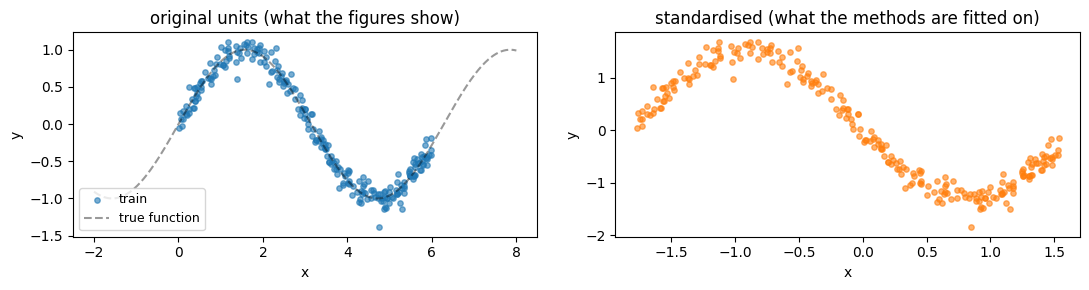

In [2]:
data = testyyy_data.make_toy_data(seed=SEED)

# `make_toy_data` calls the project's `set_seed`, which switches torch's default
# dtype to float64. The legacy methods build float32 tensors explicitly, so put
# the default back before any model is constructed. This touches no data values
# -- see testyyy_data.py's docstring.
testyyy_data.restore_float32_default()
np.random.seed(SEED)
torch.manual_seed(SEED)

std = data.standardiser

# What e1_toy.py hands to fit()/predict(): the standardised arrays.
X_train, y_train = data.x_train_std, data.y_train_std
X_eval = data.x_test_std

# Original units, for the figures only.
X_train_raw, y_train_raw = data.x_train, data.y_train
X_eval_raw = data.x_test
y_eval_raw = testyyy_data.true_function(X_eval_raw).ravel()   # clean sin(x), the dashed line


def show(y_pred, y_std, title, out_path):
    """Un-standardise a prediction, then plot it in original y units.

    A variance scales by `y_std ** 2` (`Standardiser.unstandardise_var`), so a
    standard deviation scales by `y_std`. Getting that wrong would leave the
    mean right and every band wrong by a constant factor.
    """
    mean = std.unstandardise_mean(y_pred)
    sd = y_std * std.y_std
    plot_uncertainty_for_1d_data(X_train_raw, y_train_raw, X_eval_raw, y_eval_raw,
                                 mean, sd, title, out_path)


print(f"train {X_train_raw.shape} on [{X_train_raw.min():.2f}, {X_train_raw.max():.2f}]  (uniform draws)")
print(f"eval  {X_eval_raw.shape} on [{X_eval_raw.min():.1f}, {X_eval_raw.max():.1f}]")
print(f"standardiser: x_mean={float(std.x_mean[0]):.4f}, x_std={float(std.x_std[0]):.4f}, "
      f"y_mean={std.y_mean:.4f}, y_std={std.y_std:.4f}")
print("regions: " + ", ".join(f"{k}={int(v.sum())}" for k, v in data.regions.items()))
print(f"fitting on standardised arrays: x_train_std in "
      f"[{X_train.min():.2f}, {X_train.max():.2f}], y_train_std in [{y_train.min():.2f}, {y_train.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].scatter(X_train_raw, y_train_raw, s=15, alpha=0.6, label="train")
axes[0].plot(X_eval_raw, y_eval_raw, "k--", alpha=0.4, label="true function")
axes[0].set_title("original units (what the figures show)")
axes[1].scatter(X_train, y_train, s=15, alpha=0.6, color="C1")
axes[1].set_title("standardised (what the methods are fitted on)")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
axes[0].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## Laplace approximation

Last layer, full Hessian; prior precision tuned by marginal likelihood.

noise_std_ = 0.1373


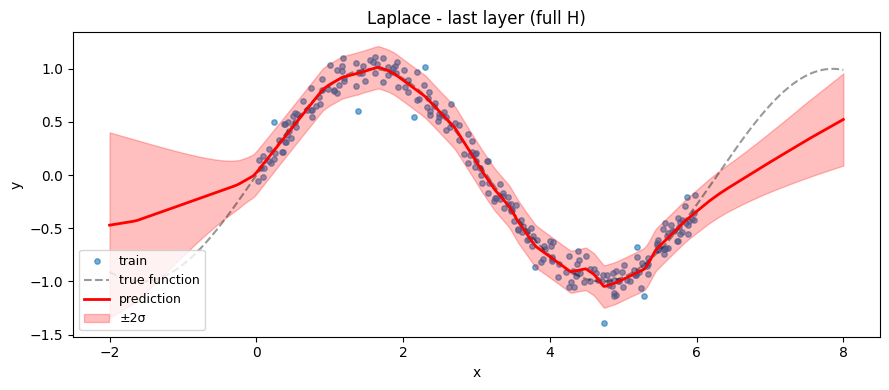

In [3]:
nn_map = train_mlp(X_train, y_train, epochs=1000, seed=SEED)
print(f"noise_std_ = {nn_map.noise_std_:.4f}")

y_pred, y_std = laplace_ll_predict(nn_map, X_train, y_train, X_eval)
show(y_pred, y_std, "Laplace - last layer (full H)", f"{FIGDIR}/protocol_laplace.png")

## Gaussian process

1.91**2 * RBF(length_scale=1.22) + WhiteKernel(noise_level=0.0212)


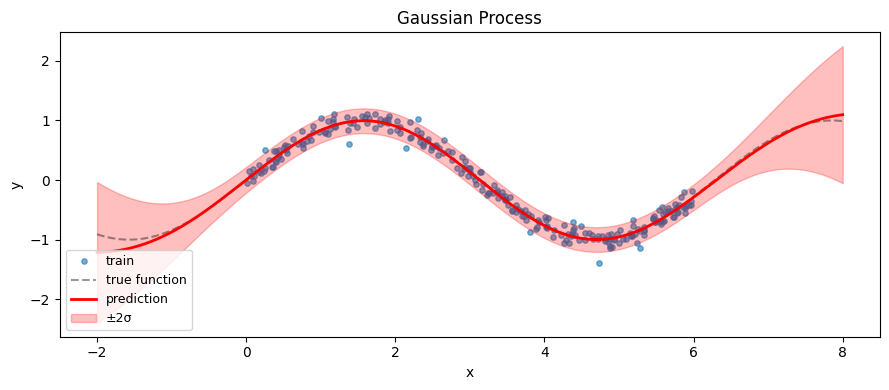

In [4]:
gp = make_gp(random_state=SEED).fit(X_train, y_train)
print(gp.kernel_)

y_pred, y_std = gp.predict(X_eval, return_std=True)
show(y_pred, y_std, "Gaussian Process", f"{FIGDIR}/protocol_gp.png")

## Monte Carlo dropout

(Gal & Ghahramani 2016). The aleatoric part is the scalar residual `noise_std_` measured after training, not the network's log-variance head -- which is why the band below barely widens away from the data.

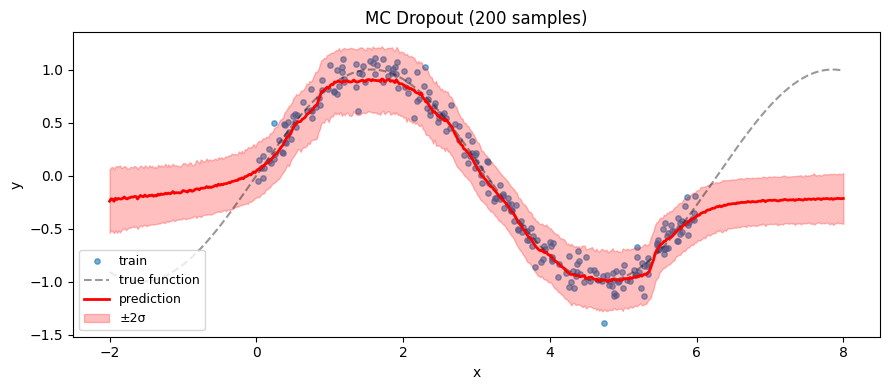

In [5]:
nn_dropout = train_mlp(X_train, y_train, dropout=0.2, epochs=1000, seed=SEED)
y_pred, y_std = mc_dropout_predict(nn_dropout, X_eval, n_samples=200)
show(y_pred, y_std, "MC Dropout (200 samples)", f"{FIGDIR}/protocol_mcdropout.png")

## Deep ensemble

Ten MAP networks; member *i* is trained with `seed=i` -- that indexing is baked into the legacy `train_ensemble`, so it does not follow `SEED`.

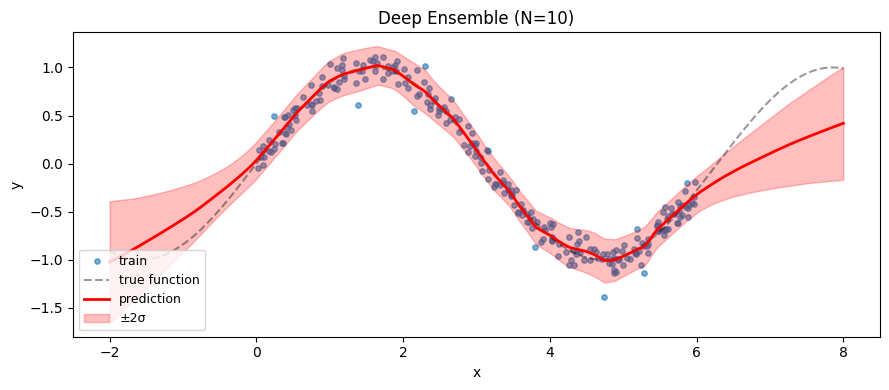

In [6]:
ensemble = train_ensemble(X_train, y_train, n_models=10, epochs=1000)
y_pred, y_std = ensemble_predict(ensemble, X_eval)
show(y_pred, y_std, f"Deep Ensemble (N={len(ensemble)})", f"{FIGDIR}/protocol_ensemble.png")

## Variational inference (Bayes by Backprop)

KL warm-up: the weight is held at 0 for the first half of training, then ramped linearly to `1 / (N * n_vi)` -- of order 1e-6, so this is close to MAP with a decorative KL term.

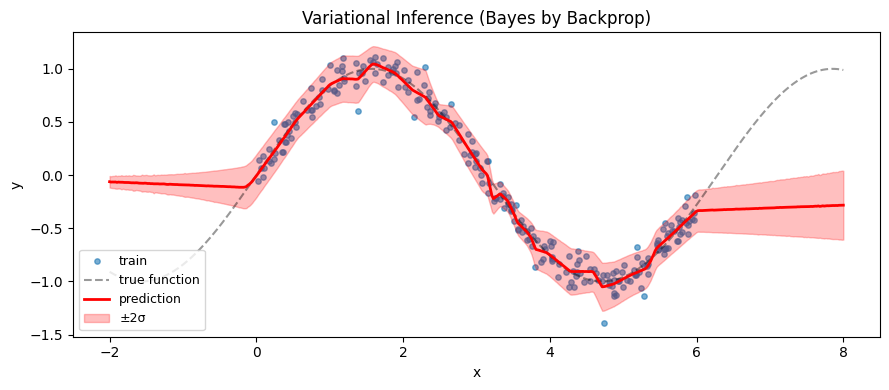

In [7]:
vi_model = train_vi(X_train, y_train, epochs=1000, seed=SEED)
y_pred, y_std = vi_predict(vi_model, X_eval)
show(y_pred, y_std, "Variational Inference (Bayes by Backprop)", f"{FIGDIR}/protocol_vi.png")